<img src="./ost_logo.png" width="240"  align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br> 
<a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>


# SARSA Reinforcement Learning

inspired by: [Bex Tuychiev](https://www.datacamp.com/portfolio/bexgboost)



In this exercise, you'll learn SARSA, an **on-policy** reinforcement learning algorithm. Understand its update rule, hyperparameters, and differences from Q-learning with practical Python examples and its implementation. You will learn how SARSA works and how you can implement it in Python. 



- Reinforcement learning (RL) is a powerful machine learning paradigm. In RL, software, usually called an agent, learns to interact with environments to solve complex problems through trial and error, all without human intervention. Among RL algorithms, SARSA stands out for its efficient on-policy nature.
- SARSA stands for **State-Action-Reward-State-Action**, representing a cycle the agent follows to solve problems. This cycle allows the agent to learn from its past mistakes and occasionally venture out to try new things. This behavior makes the algorithm particularly effective in specific problem types and differentiates it from off-policy algorithms like Q-learning.

### What is SARSA? 
- SARSA, short for State-Action-Reward-State-Action ($s-a-r-s'-a'$) describes a sequence of events in a learning process. It is an effective learning method for computer programs (agents) to make good decisions in various scenarios.
- The main idea behind SARSA is trial and error. The agent takes an action in a situation, observes the result, and adjusts its strategy based on the outcome (good or bad). This process is repeated many times, leading to improvements in the agent’s decisions over time.

It is like a robot learning to ride a bike by actually riding it, falls and all, instead of finding the shortest path from A to B by using protective training wheels.

Let's first import a few dependencies we'll need.




In [1]:
# !pip install "gymnasium[atari]" numpy matplotlib
# !pip install autorom[accept-rom-license]  # Downloading Gym env data files

###  The Taxi-V3 Environment
Throughout the exercise, we will use the Taxi-v3 environment, which is a classic reinforcement learning problem provided by the Gymnasium library. It simulates a taxi driver navigating a 5x5 grid world to pick up and drop off passengers. To load the environment, we use the .make() method of Gymnasium with an rgb_array render mode (to visualize the environment later):

In [2]:
import gymnasium as gym
env = gym.make('Taxi-v3', render_mode='rgb_array')

The environment is a 5x5 grid with four designated locations: red (R), green (G), yellow (Y), and blue (B). The taxi starts at a random square and must pick up a passenger at one of the colored locations and drop them off at another. The taxi can move North, South, East, or West and can also attempt to pick up or drop off a passenger.

Here is how we can visualize the initial state of the environment with Matplotlib:

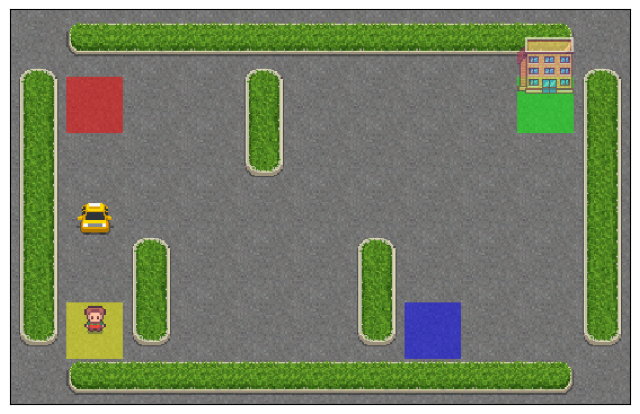

In [3]:
import matplotlib.pyplot as plt

# Reset the environment to get an initial state
# Each time we reset the environment, we get a new random state
initial_state, _ = env.reset()
# Render the initial state
img = env.render()
# Create a figure and display the environment
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
# Remove axis ticks
ax.set_xticks([])
ax.set_yticks([]);

First, we reset the environment to get an initial state. Then, we display this initial state with the render function, receiving a Numpy image array. Matplotlib's imshow() function takes this array and produces a clean visualization without axis ticks.

- Take a moment to understand the layout of the Taxi-v3 grid world, noting the taxi’s position, the barriers, passenger locations, and the destination.
- The agent (the taxi) receives +20 points for successfully dropping off a passenger. Illegal pick-up or drop-off results in -10 reward. 
- All the while, every time step produces -1 reward to encourage the taxi to complete the task quickly.
- A single episode of the Taxi-v3 environment terminates in the case of a successful drop-off or when the maximum number of time steps is reached.

In [4]:
# The number of states and actions
n_states = env.observation_space.n
n_actions = env.action_space.n
print(n_states)
print(n_actions)

500
6


There are 500 states in the environment’s state space. Each state is represented by:

- Taxi row (0–4)
- Taxi column (0–4)
- Passenger location (0–3 for R, G, Y, B, or 4 for inside the taxi)
- Destination location (0–3 for R, G, Y, B)
- Total states =  5 (rows)×5 (columns)×5 (passenger locations)×4 (destination locations)=500.

The action codes are:

| Action Code | Direction          |
|-------------|--------------------|
| 0           | Move South         |
| 1           | Move North         |
| 2           | Move East          |
| 3           | Move West          |
| 4           | Pickup passenger   |
| 5           | Drop off passenger |


The goal is for the agent to learn an optimal policy to maximize its total reward by efficiently picking up and dropping off passengers.

## SARSA Interaction Loop

First, we define how many episodes we want the interaction to continue. A single episode represents a complete run of the taxi task, from the initial state to either successfully dropping off the passenger or reaching the maximum number of time steps. Each episode allows the agent to learn from its experiences and improve its strategy over time.


In [5]:
n_episodes = 5000


The following code demonstrates the basic SARSA interaction cycle without implementing any learning algorithm. The agent always uses random actions:

- Reset the environment at the start of each episode — ($s$), `env.reset()`.
- Take a random action — ($a$), `env.step(action)`. This version uses random actions to demonstrate the interaction loop.
- Receive reward ($r$) and the next state ($s'$), `next_state, reward, ... = env.take(action)`.
- Take action ($a'$) in the new state.

In the above interaction loop, the taxi keeps moving around the environment in all directions and performing random actions until the time steps run out.

In [6]:
for episode in range(n_episodes):
   state, _ = env.reset()
   done = False
   total_reward = 0
   steps = 0
   while not done:
       # Choose a random action
       action = env.action_space.sample()
       # Take the action and observe the result
       next_state, reward, terminated, truncated, _ = env.step(action)
       done = terminated or truncated
       # Update total reward and step count
       total_reward += reward
       steps += 1
       # Move to the next state
       state = next_state
   if episode % 1000 == 0:
       print(f"Episode {episode}, Total Reward: {total_reward}, Steps: {steps}")

Episode 0, Total Reward: -713, Steps: 200
Episode 1000, Total Reward: -677, Steps: 200
Episode 2000, Total Reward: -803, Steps: 200
Episode 3000, Total Reward: -893, Steps: 200
Episode 4000, Total Reward: -884, Steps: 200


Now, we store the rewards per episode in lists and plot them:

In [11]:
import gymnasium as gym
import matplotlib.pyplot as plt

n_episodes = 10000

# --- Setup ---
# Create the environment (e.g., CartPole)
env = gym.make("CartPole-v1")


# Lists to store the results from each episode
rewards_per_episode = []
steps_per_episode = []

# --- Training Loop ---
for episode in range(n_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    steps = 0
    
    while not done:
        # Choose a random action
        action = env.action_space.sample()
        
        # Take the action and observe the result
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Update total reward and step count
        total_reward += reward
        steps += 1
        
        # Move to the next state
        state = next_state

    # --- Store results after the episode ends ---
    rewards_per_episode.append(total_reward)
    steps_per_episode.append(steps)
    
    # Optional: print progress
    if (episode + 1) % 1000 == 0:
        print(f"Episode {episode + 1}/{n_episodes} finished.")

env.close()



Episode 1000/10000 finished.
Episode 2000/10000 finished.
Episode 3000/10000 finished.
Episode 4000/10000 finished.
Episode 5000/10000 finished.
Episode 6000/10000 finished.
Episode 7000/10000 finished.
Episode 8000/10000 finished.
Episode 9000/10000 finished.
Episode 10000/10000 finished.


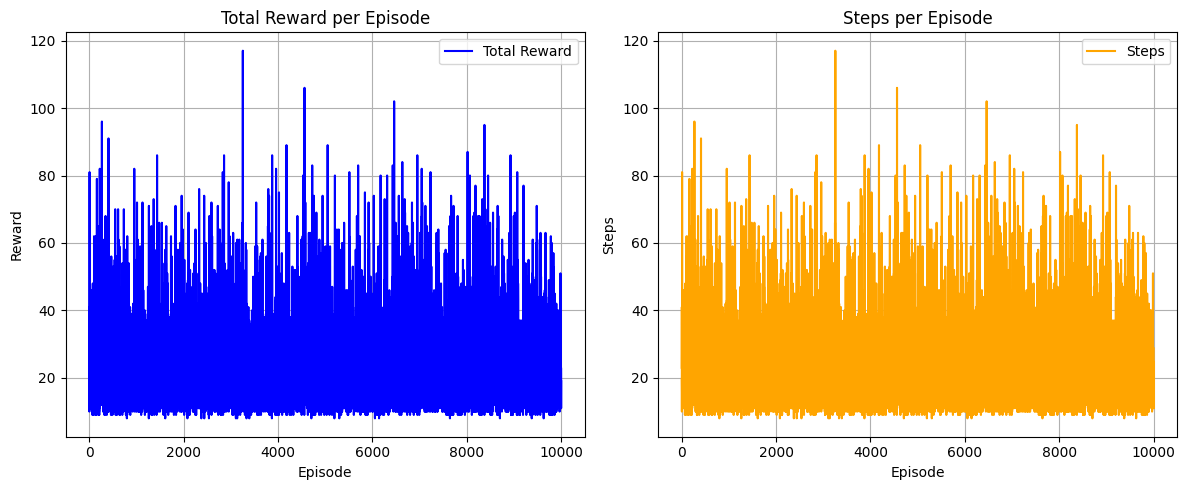

In [12]:
# --- Plotting the results ---

episodes = range(1, n_episodes + 1)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot 1: Total reward per episode
plt.subplot(1, 2, 1)
plt.plot(episodes, rewards_per_episode, label='Total Reward', color='blue')
plt.title('Total Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.grid(True)

# Plot 2: Steps per episode
plt.subplot(1, 2, 2)
plt.plot(episodes, steps_per_episode, label='Steps', color='orange')
plt.title('Steps per Episode')
plt.xlabel('Episode')
plt.ylabel('Steps')
plt.legend()
plt.grid(True)

# Show the plots
plt.tight_layout()
plt.show()

### Animating the SARSA Interaction Loop

Before we continue, let’s implement a feature to animate our interaction loops. This allows us to visually see the taxi interacting with the environment.

Creating the animation will be a simple process:
- At each time step, we capture the environment’s state in an image array using the env.render() function.
- We collect the image arrays in a separate variable.
- Using a library called moviepy, we concatenate all image arrays to create a single GIF.


In [13]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
n_episodes = 1
frames = []  # for animation
for episode in range(n_episodes):
   # Reset the environment
   state, _ = env.reset()
   # Capture the state as an image
   img = env.render()
   frames.append(img)
   done = False
   total_reward = 0
   steps = 0
   while not done:
       # Choose a random action
       action = env.action_space.sample()
       # Take the action and observe the result
       next_state, reward, terminated, truncated, _ = env.step(action)
       done = terminated or truncated
      
       # Capture the next state as an image
       img = env.render()
       frames.append(img)
       # Update total reward and step count
       total_reward += reward
       steps += 1
       # Move to the next state
       state = next_state

In [14]:
len(frames)

175

In [15]:
import moviepy
print(moviepy.__file__)
#dir(moviepy)

c:\Users\christoph.wuersch\.conda\envs\gym\Lib\site-packages\moviepy\__init__.py


In [16]:
import moviepy as mpy

In [17]:
from moviepy import ImageSequenceClip  # pip install moviepy

def create_gif(frames: list, filename, fps=5):
   """
   Creates a GIF animation from a list of RGBA NumPy arrays.
   Args:
       frames: A list of RGBA NumPy arrays representing the animation frames.
       filename: The output filename for the GIF animation.
       fps: The frames per second of the animation (default: 10).
   """
   clip = ImageSequenceClip(frames, fps=fps)
   clip.write_gif(filename, fps=fps)
# Example usage
create_gif(frames, "animation.gif", fps=25)  # saves the GIF locally

MoviePy - Building file animation.gif with imageio.


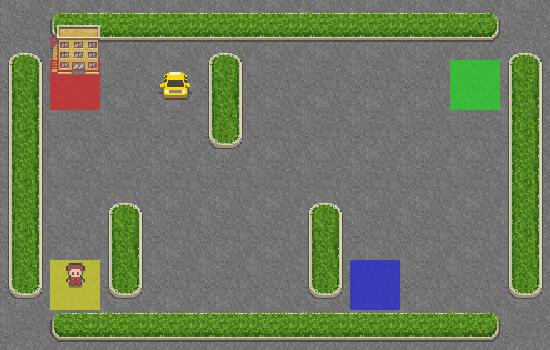

In [25]:
from IPython.display import Image

# Display the gif
Image(filename="animation.gif")


As you can see, the taxi has no idea what it is doing and didn’t even get close to the passenger. Let’s give it some brains by adding SARSA into its navigation system.

## Implementing SARSA in Python Step-by-Step

In this step, we introduce a new data structure — the Q-table. It has (number of states) x (number of actions) dimensions. The table would look like this to our agent, the taxi driver:

![Q-Table for the taxi environment](Qtable_taxi.png)

In [18]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
# Create the Taxi environment
env = gym.make("Taxi-v3", render_mode="rgb_array")

# Initialize Q-table
n_states = env.observation_space.n
n_actions = env.action_space.n
Q_table = np.zeros((n_states, n_actions))

In [19]:
 Q_table.shape


(500, 6)

Then, as the agent starts interacting with the environment guided by SARSA, it will update the Q-table with Q-values. The Q-values are scores that tell the agent which action is the best one to take, given the current state.

After initializing the Q-table, we set the hyperparameters of SARSA to common values (more on them later):

In [20]:
# SARSA parameters
alpha = 0.1  # Learning rate
gamma = 0.99  # Discount factor
epsilon = 0.1  # Exploration rate for epsilon-greedy policy
n_episodes = 20000

In [21]:
# Lists to store performance metrics
episode_rewards = []
episode_lengths = []

Epsilon-greedy policy for taking action: In the previous section, our agent was unguided — it was taking random actions. We want to change that by giving the driver an Epsilon-Greedy strategy:

In [ ]:
def epsilon_greedy(state, epsilon):
   if np.random.random() < epsilon:
       # Take random action - explore
       return env.action_space.sample()
   else:
       # Take action with the highest Q-value - exploit
       # (SARSA uses the next action's Q-value, but for action selection we use the current state's Q-values: on policy method )
       return np.argmax(Q_table[state])

This strategy is intended to control the crucial balance between exploration and exploitation. With probability `epsilon`, the agent explores the environment by taking a random action, while with probability `1-epsilon`, it exploits its current knowledge by choosing the action with the highest Q-value from the Q-table. This approach allows the agent to discover new, potentially better strategies while also using what it has already learned.


Finally, we write the SARSA training loop. The beginning of the loop is already familiar to us. The only difference is that we use the `epsilon_greedy()` function to tell us which action to take in the current state:

In [23]:
# SARSA training loop
for episode in range(n_episodes):
   state, _ = env.reset()
   action = epsilon_greedy(state, epsilon)
   done = False
   total_reward = 0
   steps = 0
   while not done:
       next_state, reward, terminated, truncated, _ = env.step(action)
       done = terminated or truncated
       next_action = epsilon_greedy(next_state, epsilon)
       Q_table[state, action] += alpha * (
           reward + gamma * Q_table[next_state, next_action] - Q_table[state, action]
       )
       state = next_state
       action = next_action
       total_reward += reward
       steps += 1
   episode_rewards.append(total_reward)
   episode_lengths.append(steps)
   if episode % 2000 == 0:
       avg_reward = np.mean(episode_rewards[-1000:])
       avg_length = np.mean(episode_lengths[-1000:])
       print(f"Episode {episode}, Avg Reward: {avg_reward:.2f}, Avg Length: {avg_length:.2f}")

Episode 0, Avg Reward: -704.00, Avg Length: 200.00
Episode 2000, Avg Reward: -5.05, Avg Length: 19.74
Episode 4000, Avg Reward: 2.22, Avg Length: 14.75
Episode 6000, Avg Reward: 2.44, Avg Length: 14.65
Episode 8000, Avg Reward: 1.88, Avg Length: 14.86
Episode 10000, Avg Reward: 2.36, Avg Length: 14.90
Episode 12000, Avg Reward: 2.61, Avg Length: 14.62
Episode 14000, Avg Reward: 2.43, Avg Length: 14.91
Episode 16000, Avg Reward: 2.68, Avg Length: 14.59
Episode 18000, Avg Reward: 2.40, Avg Length: 14.80


The update rule comes from the following formula:

$$\boxed{Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma Q(s', a') - Q(s, a) \right]}$$

As you can see from the output, the average reward and the number of time steps per episode went down dramatically as we ran more and more episodes.

We can see this visually by plotting the episode_rewards and episode_lengths arrays:

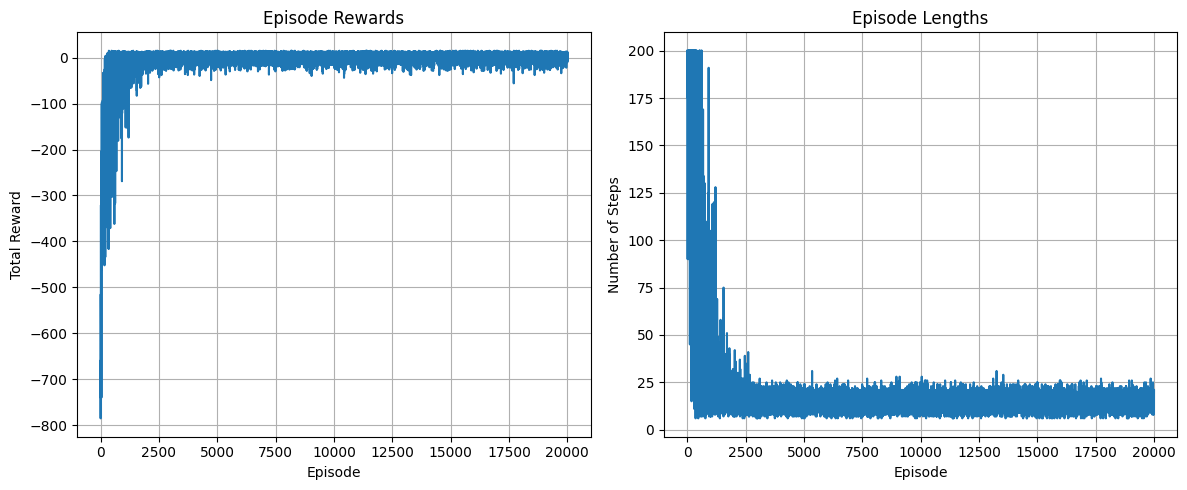

In [26]:
# Plot the learning curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(episode_rewards)
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Total Reward"); plt.grid()
plt.subplot(1, 2, 2)
plt.plot(episode_lengths)
plt.title("Episode Lengths")
plt.xlabel("Episode")
plt.ylabel("Number of Steps")
plt.tight_layout(); plt.grid()
plt.show()

The left plot displays the total reward obtained in each episode. We can observe that:

- Initially, the rewards are low and highly variable, indicating that the agent is exploring and learning.
- Over time, there’s an upward trend in the rewards, suggesting that the agent is improving its policy.
- Towards the end, the rewards seem to stabilize at a higher level, indicating that the agent has learned a reasonably good policy.

The right plot shows the number of steps taken in each episode. We can see that:

- At the beginning, episodes tend to be longer, as the agent is taking suboptimal actions.
- As learning progresses, there’s a general downward trend in episode length.
- The episode lengths eventually stabilize, suggesting that the agent has learned to complete the task more efficiently.

## Organize the code into functions and add comments to explain each part.

First, a function to create an environment:

In [39]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from moviepy import ImageSequenceClip
from IPython.display import Image

def create_environment(env_name="Taxi-v3", render_mode="rgb_array"):
   """Create and return a Gymnasium environment."""
   return gym.make(env_name, render_mode=render_mode)

Then, a function to initialize a Q-table given an environment:

In [40]:
def initialize_q_table(env):
   """Initialize and return a Q-table for the given environment."""
   n_states = env.observation_space.n
   n_actions = env.action_space.n
   return np.zeros((n_states, n_actions))

The Epsilon-greedy strategy that accepts an environment, a Q-table, current state and epsilon:

In [41]:
def epsilon_greedy(env, Q_table, state, epsilon=0.1):
   """Epsilon-greedy action selection."""
   if np.random.random() < epsilon:
       return env.action_space.sample()
   else:
       return np.argmax(Q_table[state])

Finally, a large function to train the agent with SARSA that requires an environment, the number of episodes to run, alpha, gamma, and epsilon parameters:

In [42]:
def train_sarsa(env, n_episodes=20000, alpha=0.1, gamma=0.99, epsilon=0.1):
   """Train the agent using SARSA algorithm."""
   Q_table = initialize_q_table(env)
   episode_rewards = []
   episode_lengths = []
   for episode in range(n_episodes):
       state, _ = env.reset()
       action = epsilon_greedy(env, Q_table, state, epsilon)
       done = False
       total_reward = 0
       steps = 0
       while not done:
           next_state, reward, terminated, truncated, _ = env.step(action)
           done = terminated or truncated
           next_action = epsilon_greedy(env, Q_table, next_state, epsilon)
           sarsa_update(
               Q_table, state, action, reward, next_state, next_action, alpha, gamma
           )
           state = next_state
           action = next_action
           total_reward += reward
           steps += 1
       episode_rewards.append(total_reward)
       episode_lengths.append(steps)
   return Q_table, episode_rewards, episode_lengths

Also, a function to plot performance metrics:


In [43]:
def plot_learning_curve(episode_rewards, episode_lengths):
   """Plot the learning curve."""
   plt.figure(figsize=(12, 5))
   plt.subplot(1, 2, 1)
   plt.plot(episode_rewards)
   plt.title("Episode Rewards")
   plt.xlabel("Episode")
   plt.ylabel("Total Reward")
   plt.subplot(1, 2, 2)
   plt.plot(episode_lengths)
   plt.title("Episode Lengths")
   plt.xlabel("Episode")
   plt.ylabel("Number of Steps")
   plt.tight_layout()
   plt.show()

SARSA’s update rule, which requires a Q-table, the current state, the taken action in that state, the reward for the action, the next state and action:

In [44]:
def sarsa_update(Q_table, state, action, reward, next_state, next_action, alpha, gamma):
   """Perform SARSA update on Q-table."""
   Q_table[state, action] += alpha * (
       reward + gamma * Q_table[next_state, next_action] - Q_table[state, action]
   )

Our previous `create_gif()` function:

In [45]:
def create_gif(frames, filename, fps=5):
   """Creates a GIF animation from a list of frames."""
   clip = ImageSequenceClip(frames, fps=fps)
   clip.write_gif(filename, fps=fps)

And one other function to run a single episode with rendering using a complete, learned Q-table (for animation purposes):

In [47]:
def run_episode(env, Q_table, epsilon=0):
   """Run a single episode using the learned Q-table."""
   state, _ = env.reset()
   done = False
   total_reward = 0
   frames = [env.render()]
   while not done:
       action = epsilon_greedy(env, Q_table, state, epsilon)
       next_state, reward, terminated, truncated, _ = env.step(action)
       done = terminated or truncated
       frames.append(env.render())
       total_reward += reward
       state = next_state
   return frames, total_reward

Now, let’s execute everything:

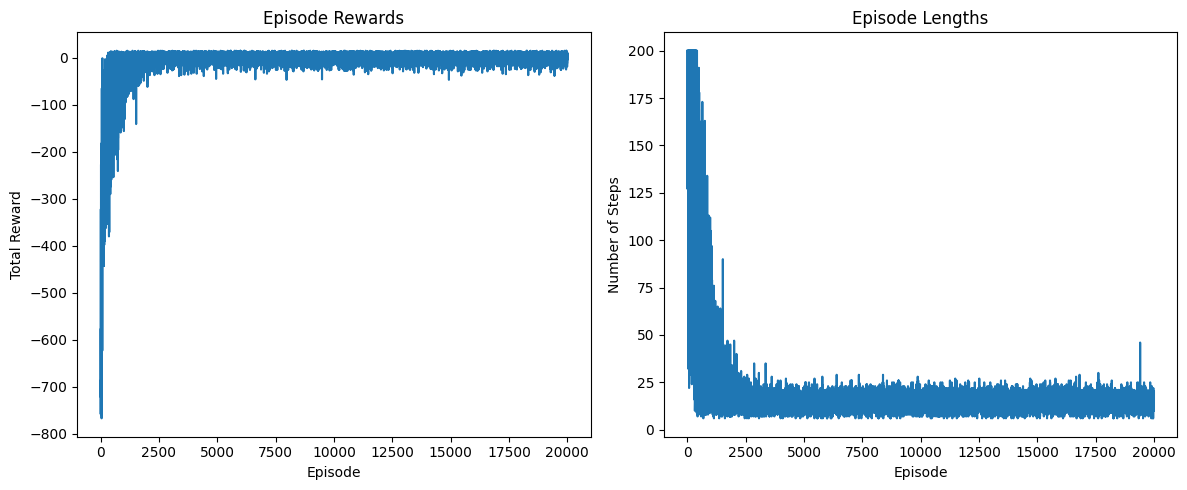

MoviePy - Building file ./sarsa_animation_1.gif with imageio.


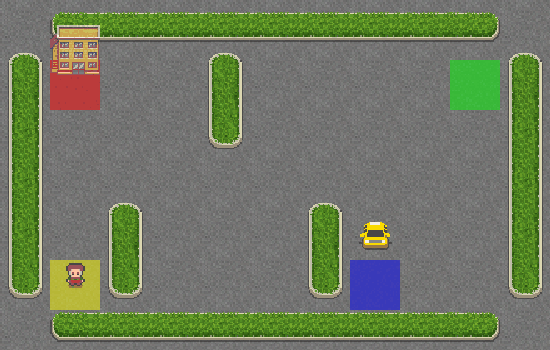

In [48]:

env = create_environment()
  
Q_table, episode_rewards, episode_lengths = train_sarsa(env, n_episodes=20000, alpha=0.1, gamma=0.99, epsilon=0.1)
plot_learning_curve(episode_rewards, episode_lengths)
  
frames, total_reward = run_episode(env, Q_table)
create_gif(frames, "./sarsa_animation_1.gif", fps=1)


# Display the gif
Image(filename="./sarsa_animation_1.gif")

## SARSA vs. Q-learning: Key Differences

Though SARSA and Q-learning are both widely used reinforcement learning algorithms, they do have some important differences. And those differences are critical to understanding when and how to use each algorithm.

**On-policy vs. off-policy:** An on-policy algorithm, SARSA, learns the value of the policy it follows, including even the steps taken during exploration. Q-learning is off-policy; it learns the value of the optimal policy—even when it’s not following that policy, it still learns the value of the optimal policy when it ultimately reaches the end of the episode. That’s why we mentioned in the beginning that SARSA must be used when the learning journey is just as important as the outcome itself. Q-learning doesn’t care about the learning journey much.

Update rule: SARSA

$$\boxed{Q(s,a)=Q(s,a)+\alpha \cdot \left[ r + \gamma Q(s',a')-Q(s,a)\right]}$$

Update rule: Q-learning

$$\boxed{Q(s,a)=Q(s,a)+\alpha \cdot \left[ r + \gamma \max_{a'} \lbrace Q(s',a') \rbrace-Q(s,a)\right]}$$

- When updating the Q-values, SARSA does not ignore the exploration policy and is thus more conservative. In comparison, Q-learning always assumes that the agent will take the optimal action in the future and is therefore more aggressive.
- While both algorithms eventually reach the optimal policy, Q-learning can often learn more quickly, particularly in deterministic environments.
- In environments where exploration can lead to bad outcomes, SARSA generally learns safer policies because it takes into account the actual policy being followed.
- In certain random environments, SARSA can be more stable because it takes into account the actual next action, even when that action is a suboptimal exploratory one.
- Q-learning can be more sensitive to the choice of learning rate and exploration rate, especially in environments with significant stochasticity.